# Pareto Distribution — Demo

This notebook demonstrates the **Pareto Distribution** using Python.

Topics covered:

- Generating Pareto-distributed data
- Understanding the parameters `x_m` and `alpha`
- Visualizing the distribution
- Observing the effect of `alpha`
- Calculating theoretical mean
- Comparing different values of `alpha`
- Demonstrating the concentration of values in the upper tail

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pareto

## 1. Generate Pareto Distributed Data

We use:

- `x_m = 1` → Minimum possible value
- `alpha = 2` → Shape parameter

A smaller `alpha` produces a heavier tail.

In [2]:
np.random.seed(42)

x_m = 1
alpha = 2

data = x_m * (np.random.pareto(alpha, 10000) + 1)

print("Minimum:", data.min())
print("Maximum:", data.max())
print("Mean:", data.mean())

Minimum: 1.0000058174284463
Maximum: 59.51466774589408
Mean: 1.9367232946118476


## 2. Visualize the Pareto Distribution

The histogram shows the characteristic:

- High frequency near the minimum
- Rapid decline
- Long right tail

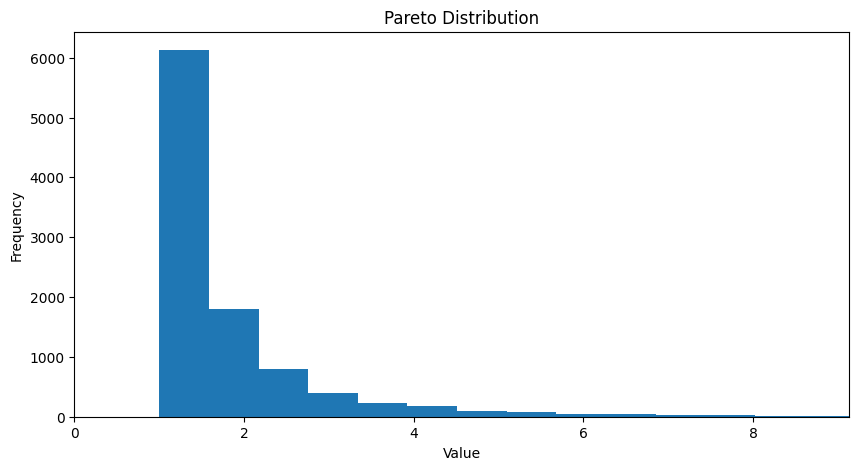

In [3]:
plt.figure(figsize=(10, 5))

plt.hist(data, bins=100)

plt.title("Pareto Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.xlim(0, np.percentile(data, 99))

plt.show()

## 3. Effect of Alpha

The parameter `alpha` controls the heaviness of the tail.

- Smaller `alpha` → heavier tail
- Larger `alpha` → faster tail decay

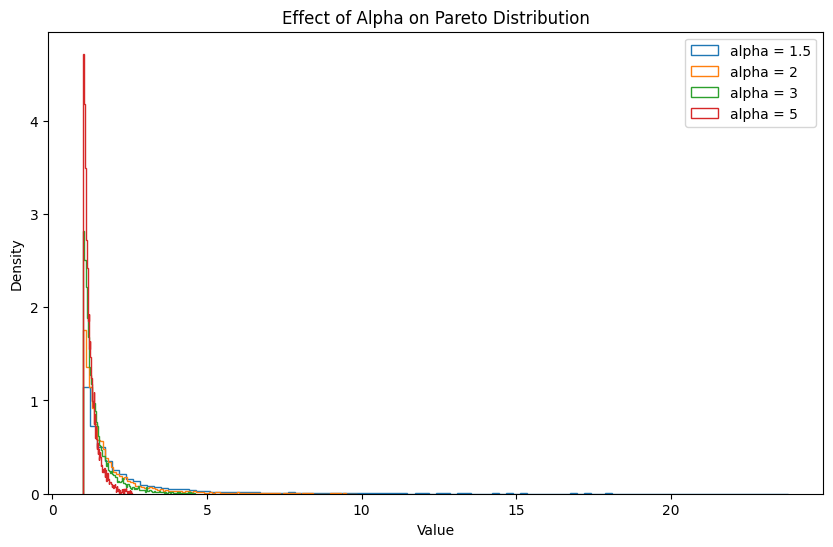

In [4]:
alphas = [1.5, 2, 3, 5]

plt.figure(figsize=(10, 6))

for alpha in alphas:
    data = x_m * (np.random.pareto(alpha, 10000) + 1)
    
    clipped_data = data[data <= np.percentile(data, 99)]
    
    plt.hist(
        clipped_data,
        bins=100,
        density=True,
        histtype="step",
        label=f"alpha = {alpha}"
    )

plt.title("Effect of Alpha on Pareto Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()

plt.show()

## 4. Theoretical Mean

For a Pareto Distribution:

$$
\mu = \frac{\alpha x_m}{\alpha - 1}
$$

The mean exists only when:

$$
\alpha > 1
$$

In [5]:
x_m = 1

for alpha in [1.5, 2, 3, 5]:
    theoretical_mean = (alpha * x_m) / (alpha - 1)
    print(f"alpha = {alpha:<3} -> theoretical mean = {theoretical_mean:.4f}")

alpha = 1.5 -> theoretical mean = 3.0000
alpha = 2   -> theoretical mean = 2.0000
alpha = 3   -> theoretical mean = 1.5000
alpha = 5   -> theoretical mean = 1.2500


## 5. Theoretical Variance

For a Pareto Distribution:

$$
\sigma^2 =
\frac{\alpha x_m^2}
{(\alpha - 1)^2(\alpha - 2)}
$$

The variance exists only when:

$$
\alpha > 2
$$

In [6]:
x_m = 1

for alpha in [1.5, 2, 2.5, 3, 5]:
    if alpha > 2:
        variance = (
            alpha * x_m**2
            / ((alpha - 1)**2 * (alpha - 2))
        )
        print(f"alpha = {alpha:<3} -> theoretical variance = {variance:.4f}")
    else:
        print(f"alpha = {alpha:<3} -> theoretical variance is undefined")

alpha = 1.5 -> theoretical variance is undefined
alpha = 2   -> theoretical variance is undefined
alpha = 2.5 -> theoretical variance = 2.2222
alpha = 3   -> theoretical variance = 0.7500
alpha = 5   -> theoretical variance = 0.1042


## 6. Pareto Distribution and the Long Tail

A Pareto Distribution can produce extremely large values.

This is one of the most important characteristics of heavy-tailed distributions.

The following example shows the largest observations in a sample.

In [7]:
np.random.seed(42)

alpha = 2
data = x_m * (np.random.pareto(alpha, 10000) + 1)

largest_values = np.sort(data)[-10:][::-1]

print("10 largest observations:")
print(largest_values)

10 largest observations:
[59.51466775 47.54919033 44.95527287 43.06031116 41.29995684 39.23229593
 35.51773654 30.21575213 30.05038912 28.78291784]


## 7. Concentration of Total Value

One reason Pareto-like behavior is important is that a relatively small
number of observations can contribute a large proportion of the total.

We sort the observations from largest to smallest and calculate the
cumulative contribution to the total.

In [8]:
sorted_data = np.sort(data)[::-1]

cumulative_share = np.cumsum(sorted_data) / sorted_data.sum()

top_20_count = int(0.20 * len(sorted_data))

top_20_share = cumulative_share[top_20_count - 1]

print(f"Top 20% of observations contribute approximately {top_20_share:.2%} of the total.")

Top 20% of observations contribute approximately 43.41% of the total.


> The result will not necessarily be exactly 80%.

The famous **80/20 Rule** is a useful interpretation of unequal
concentration, not a mathematical requirement that every Pareto sample
must produce exactly 80% of the total from the top 20%.

## 8. Log-Log Visualization

Power-law and Pareto-like behavior can often be investigated using
log-log plots.

A roughly linear pattern in the tail can be an indication of
power-law behavior.

However, a log-log plot alone is not sufficient to prove that a dataset
follows a Pareto or power-law distribution.

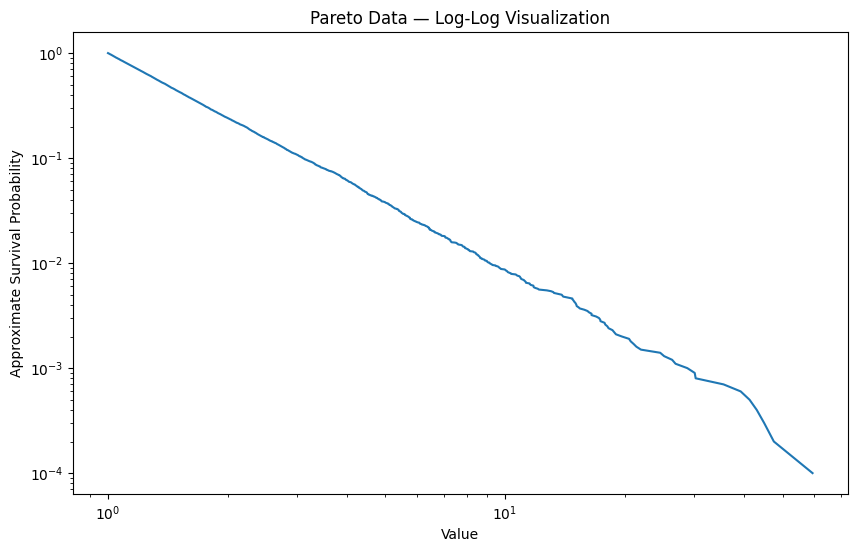

In [9]:
sorted_data = np.sort(data)

ranks = np.arange(1, len(sorted_data) + 1)

survival_probability = 1 - (ranks - 1) / len(sorted_data)

plt.figure(figsize=(10, 6))

plt.loglog(sorted_data, survival_probability)

plt.title("Pareto Data — Log-Log Visualization")
plt.xlabel("Value")
plt.ylabel("Approximate Survival Probability")

plt.show()

## 9. Key Observations

- Pareto Distribution is continuous.
- It is strongly right-skewed.
- It has a long and heavy right tail.
- `alpha` controls the tail behavior.
- Smaller `alpha` produces a heavier tail.
- The mean exists only when `alpha > 1`.
- The variance exists only when `alpha > 2`.
- Pareto-like distributions are useful for studying highly unequal data.
- The 80/20 Rule is associated with Pareto behavior but is not a strict
  requirement of the mathematical distribution.

### Quick Comparison

| Distribution | Shape | Main Characteristic |
|---|---|---|
| Normal | Symmetric | Bell curve |
| Log Normal | Right-skewed | Positive values + long right tail |
| Pareto | Strongly right-skewed | Heavy power-law tail |